In [3]:
from pathlib import Path
from references import constants
from references.analysis_config import AnalysisConfig
from references.reference import Reference
from utils.histograms import get_process_hists, normalize_hist, add_hists
from utils import functions
from bamboo_hh.variables import REG

import numpy as np
import matplotlib.pyplot as plt
import mplhep

In [4]:
%config InlineBackend.figure_format = 'retina'

In [5]:
plt.style.use(mplhep.style.CMS)
label_fontsize = 18
tick_fontsize = 18
rlabel = "13.6 TeV"
legend_fontsize = 18
cms_fontsize = 18
ylabel = "normalized events"

def get_sig_bkg_hists(reference: Reference, era, resultsdir, config, mode = "histogram"):
    processes = functions.find_mc_processes(resultsdir)
    process_hists = get_process_hists(reference, processes, era, resultsdir, config, mode)
    signal_hist = process_hists.pop('ggHH_kl_1_kt_1_bbww')
    background_hists = [hist for proc, hist in process_hists.items() if functions.process_is_bkg(proc)]
    background_hist = add_hists(background_hists)
    return signal_hist, background_hist

def plot_signal_background(reference: Reference, signal_hist, background_hist):

    normalized_signal = normalize_hist(signal_hist)
    normalized_background = normalize_hist(background_hist)

    def hist_to_numpy(hist):
        values = np.array([hist.GetBinContent(i + 1) for i in range(hist.GetNbinsX())])
        edges = np.array([hist.GetBinLowEdge(i + 1) for i in range(hist.GetNbinsX() + 1)])
        return values, edges

    sig_vals, edges = hist_to_numpy(normalized_signal)
    bkg_vals, _ = hist_to_numpy(normalized_background)

    print(len(sig_vals))
    fig, ax = plt.subplots(figsize=(8, 6))  # Square-ish

    ax.step(edges[:-1], sig_vals, where='post', color='blue', linewidth=2.0, label="Signal")
    ax.fill_between(edges[:-1], sig_vals, step='post', color='blue', alpha=0.2)

    ax.step(edges[:-1], bkg_vals, where='post', color='red', linewidth=2.0, label="Background")
    ax.fill_between(edges[:-1], bkg_vals, step='post', color='red', alpha=0.2)

    xlabel_name = REG.get_var1D_title(reference.observable_base)
    print(xlabel_name)
    # ax.set_xlabel(rf"${xlabel_name}$", fontsize=label_fontsize)
    ax.set_xlabel(reference.observable_base, fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    nbin, xmin, xmax = REG.get_var1D_binning(reference.observable_base)
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, max(sig_vals.max(), bkg_vals.max()) * 1.2)
    ax.grid(True)

    ax.legend(fontsize=legend_fontsize, loc="upper right", frameon=True)

    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fontsize, loc=0)
    ax.text(
        1.0, 1.0, rlabel,
        transform=ax.transAxes,
        fontsize=cms_fontsize,
        horizontalalignment='right',
        verticalalignment='bottom'
    )

    fig.tight_layout()
    plt.show()

### Disc_Study_New

In [6]:
workdir_name = 'JetTop_even'

projectdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New')
resultsdir = projectdir / workdir_name / 'results'
eras = functions.get_eras(resultsdir)
config = AnalysisConfig('/afs/cern.ch/user/a/anunezde/bamboodev/hh/bamboo_hh/config/disc_study_new.yml')
refs = Reference.get_refs_from_file(functions.get_root_files(resultsdir)[0])
refs.sort(key=lambda r: (r.channel_base, r.observable_base))

50
#DeltaR(jj, l)


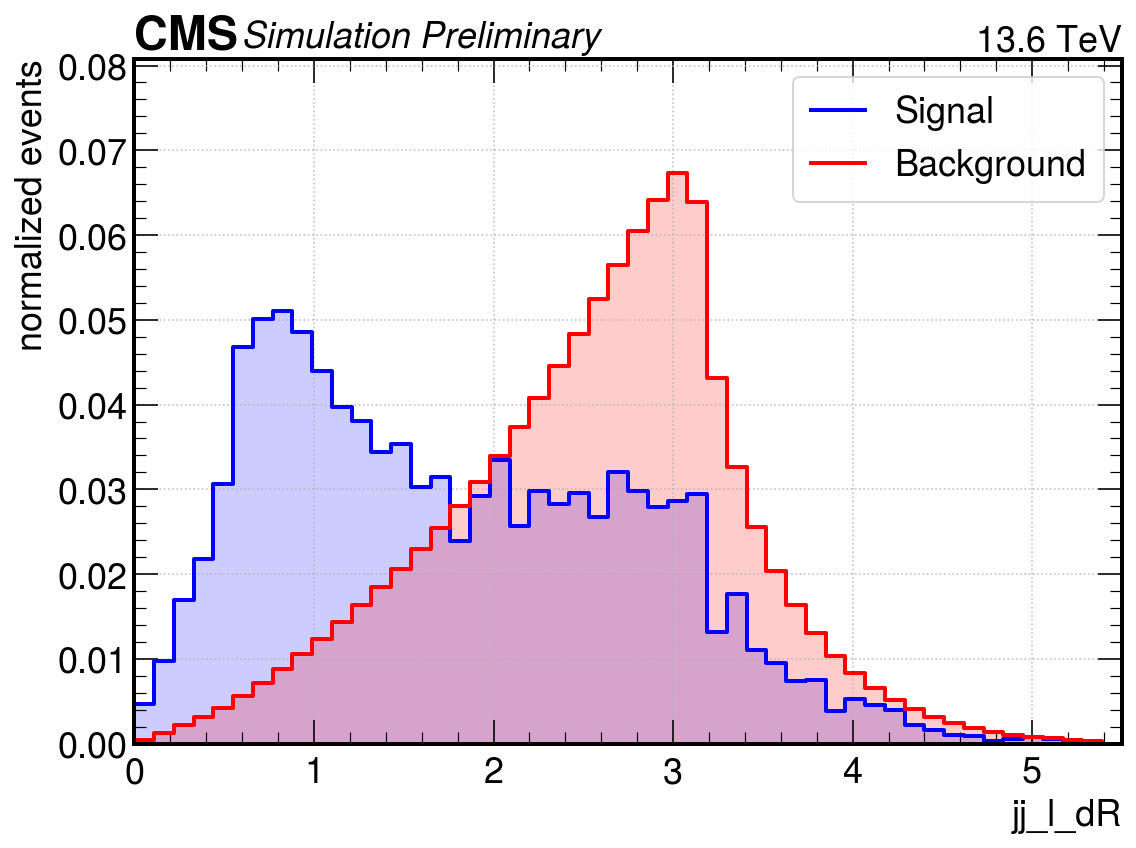

50
#DeltaR(jj, l#nu)


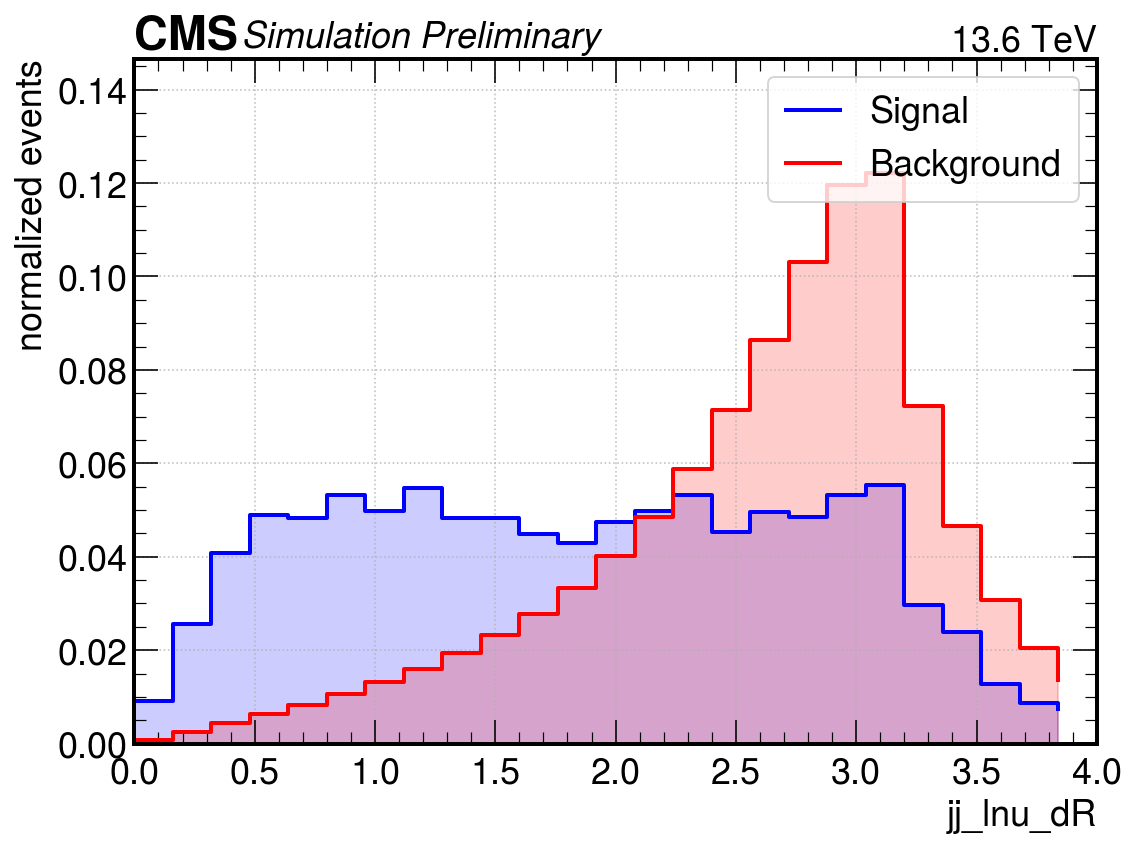

100
m_{WW}


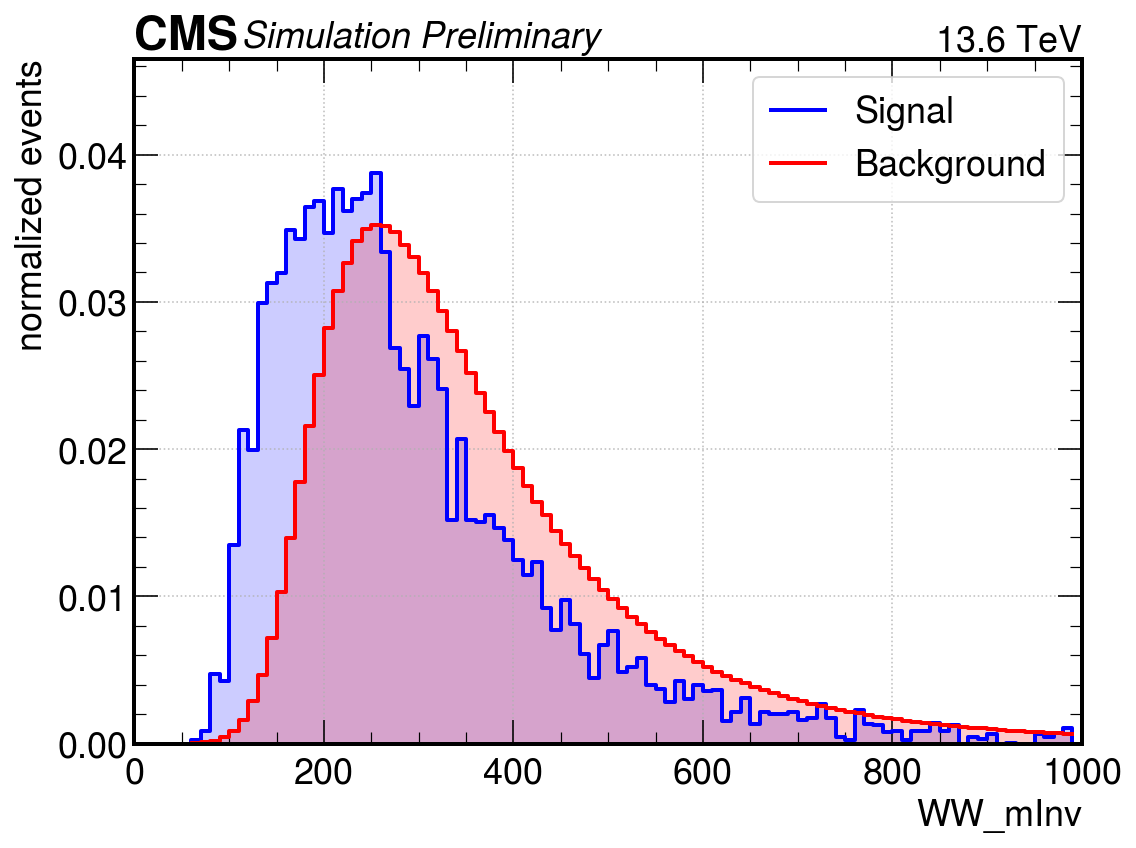

50
#Delta#phi(jj, l#nu)


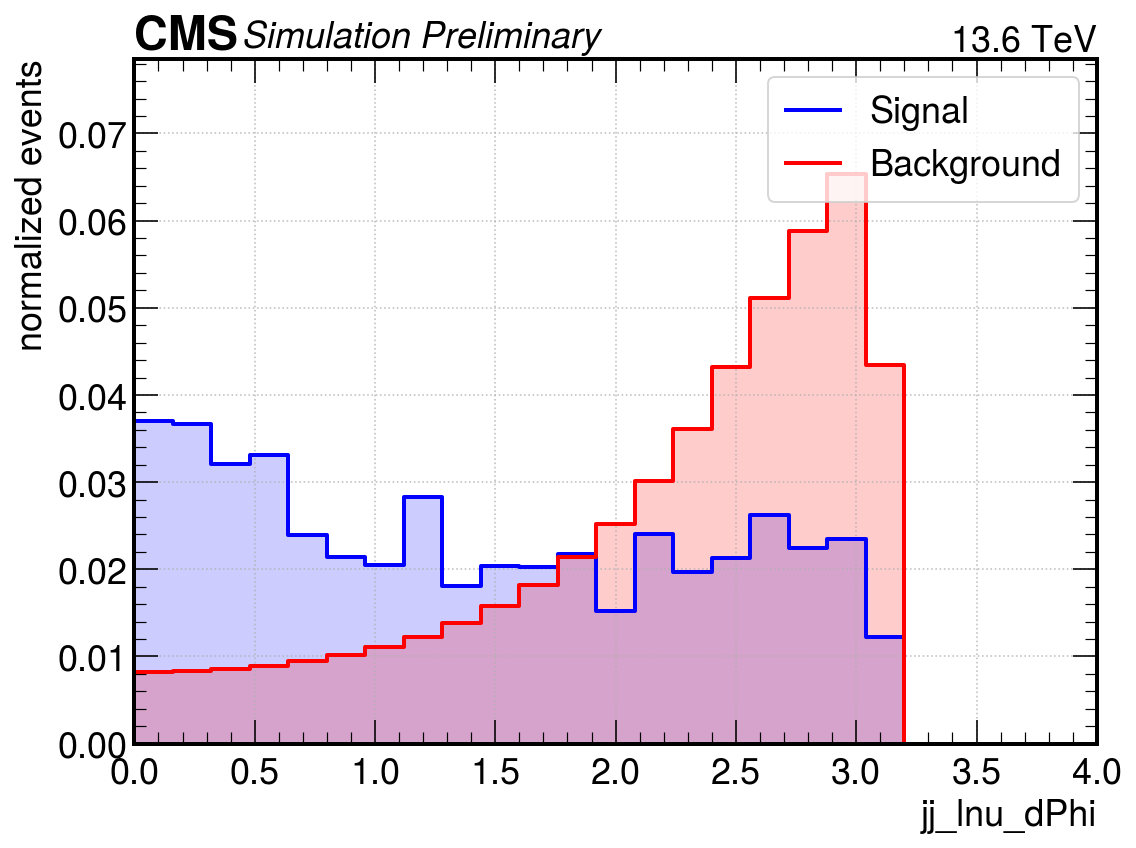

50
p_{T}^{bb}


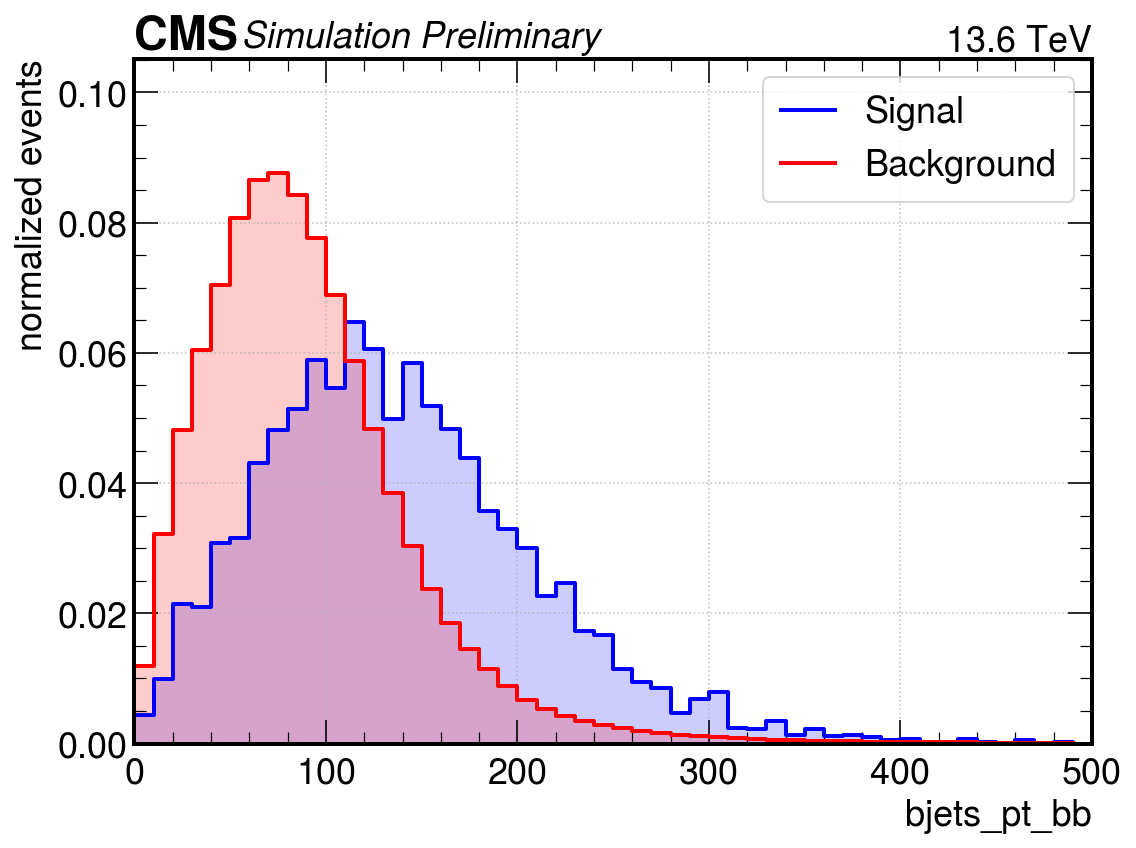

50
#Delta#phi(jj, l)


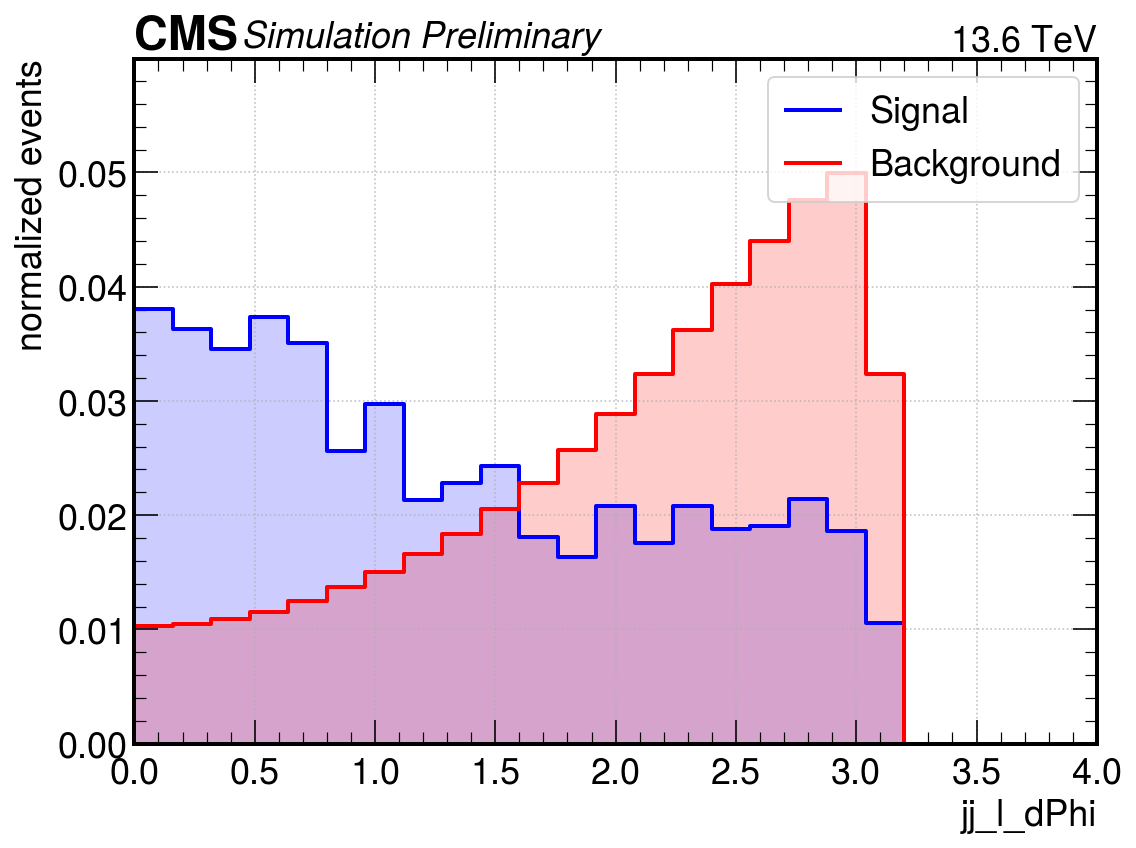

50
#DeltaR(b,b)


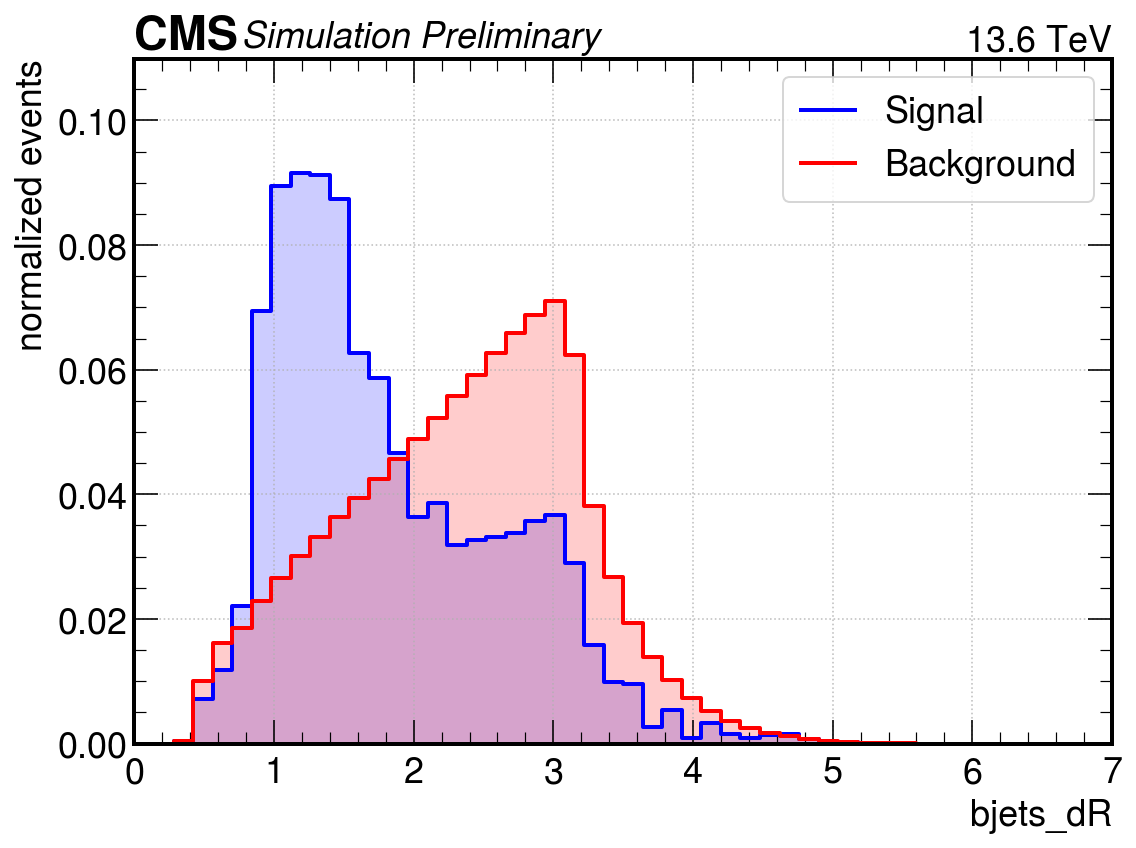

50
min_{b}(#DeltaR(b, l))


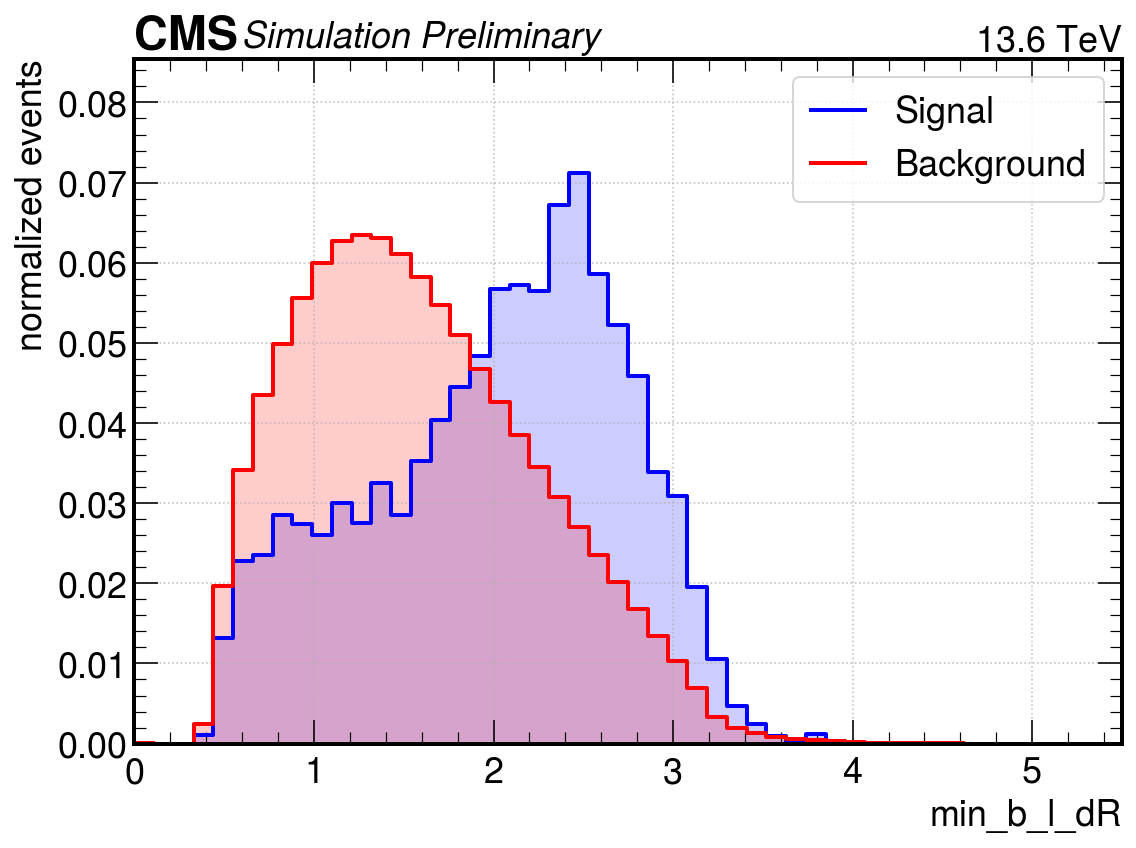

50
#Delta#phi(bjj, jj)


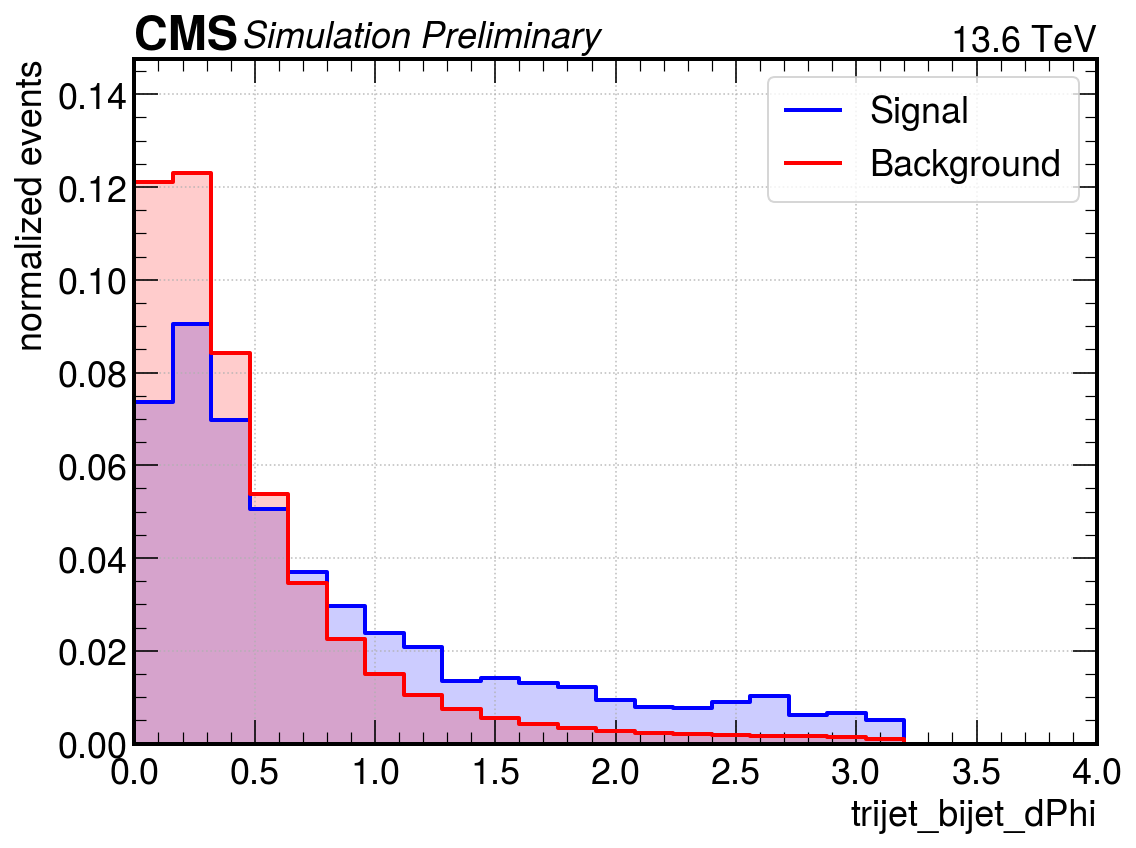

55
trijet_pt_rat


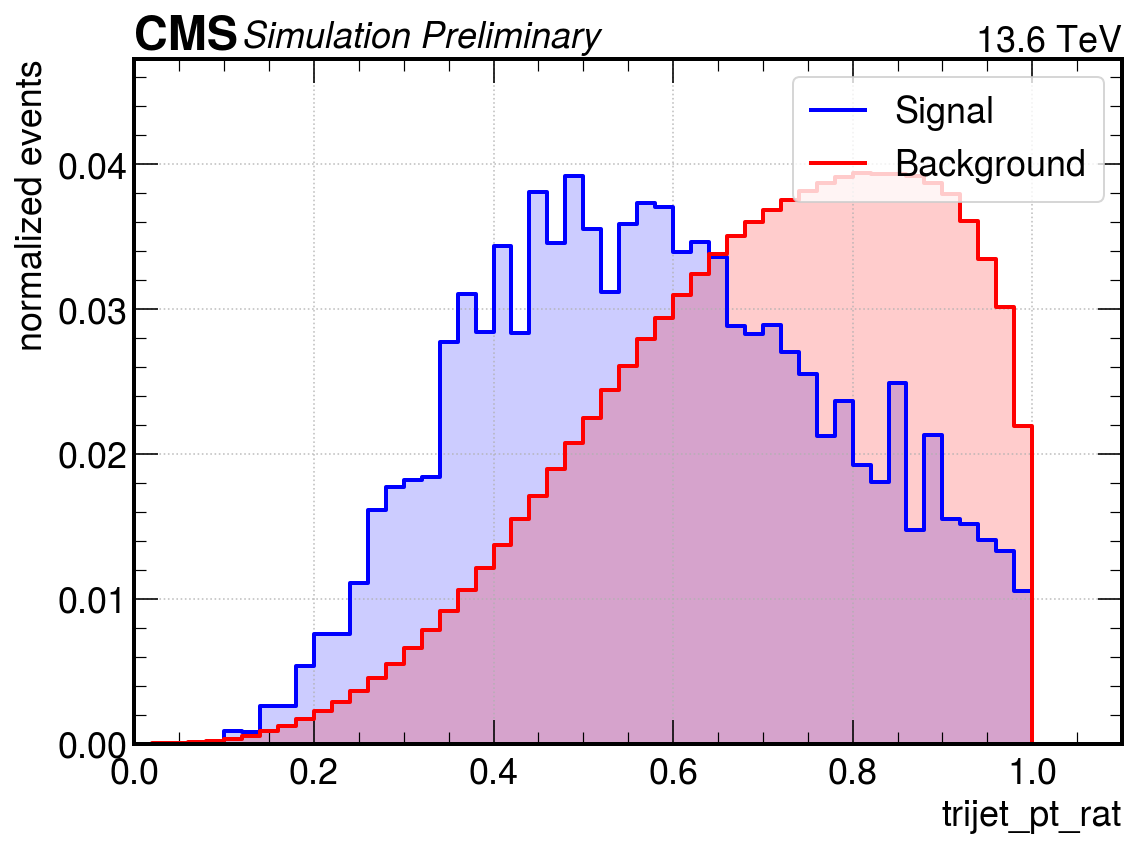

In [15]:
# var_names = [
#     'lep0_pt',                                      
#     'bjets_mbb', 'bjets_dR', 'bjets_pt_bb', 'bjet0_pt', 'bjet1_pt',         # bjet-vars
#     'blnu_mT', 'blnu_pt',                                                   # leptonic-top 
#     'trijet_mInv', 'trijet_pt', 'trijet_pt_rat', 'trijet_bijet_dR'          # hadronic-top 
# ]
var_names = ['jj_l_dR',
 'jj_lnu_dR',
 'WW_mInv',
 'jj_lnu_dPhi',
 'bjets_pt_bb',
 'jj_l_dPhi',
 'bjets_dR',
 'min_b_l_dR',
 'trijet_bijet_dPhi',
 'trijet_pt_rat']

filtered_refs = list(filter(lambda ref: ref.observable_base in var_names and ref.channel_base == 'SL_4j_resolved', refs))
sorted_refs = sorted(filtered_refs, key=lambda ref: var_names.index(ref.observable_base))
for ref in sorted_refs:
    signal_hist, bkg_hist = get_sig_bkg_hists(ref, eras[0], resultsdir, config)
    plot_signal_background(ref, signal_hist, bkg_hist)

In [ ]:
hist = get_process_hists(top_10_refs[0], processes, )